# Importing Libraries

In [2]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np 


## Step 1: Load + Merge + Filter

In [42]:
# Loading the datasets 
train = pd.read_csv('train.csv')
features = pd.read_csv('features.csv')
stores = pd.read_csv('stores.csv')

In [6]:
# Merge datasets
df = train.merge(features, on=['Store','Date'])
df = df.merge(stores, on='Store')

In [46]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])


KeyError: 'Date'

In [45]:
df.head()

,Store,Dept,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
Date,,,,,,,,,,,,,,
2010-02-05,1,1,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
2010-02-12,1,1,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2010-02-19,1,1,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
2010-02-26,1,1,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
2010-03-05,1,1,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [10]:
print(df.columns)

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'Type', 'Size'],
      dtype='str')


In [9]:
print("Train shape:", train.shape)
print("Features shape:", features.shape)
print("Stores shape:", stores.shape)
print("Merged shape:", df.shape)

Train shape: (421570, 5)
Features shape: (8190, 12)
Stores shape: (45, 3)
Merged shape: (421570, 17)


In [11]:
print(df[['Store', 'Dept']].drop_duplicates())

        Store  Dept
0           1     1
143         1     2
286         1     3
429         1     4
572         1     5
...       ...   ...
421013     45    94
421147     45    95
421290     45    96
421292     45    97
421435     45    98

[3331 rows x 2 columns]


## Step 2: Cleaning the Dataset

In [12]:
# Check missing values
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
IsHoliday_y          0
Type                 0
Size                 0
dtype: int64

In [18]:
# Remove duplicates
df = df.drop_duplicates()


In [21]:
df.columns

Index(['Store', 'Dept', 'Weekly_Sales', 'IsHoliday_x', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'Type', 'Size'],
      dtype='str')

In [24]:
df.index

DatetimeIndex(['2010-02-05', '2010-02-12', '2010-02-19', '2010-02-26',
               '2010-03-05', '2010-03-12', '2010-03-19', '2010-03-26',
               '2010-04-02', '2010-04-09',
               ...
               '2012-08-24', '2012-08-31', '2012-09-07', '2012-09-14',
               '2012-09-21', '2012-09-28', '2012-10-05', '2012-10-12',
               '2012-10-19', '2012-10-26'],
              dtype='datetime64[us]', name='Date', length=421570, freq=None)

In [25]:
df = train.merge(features, on=['Store','Date'])

In [26]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [27]:
# Only set index if Date exists
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

In [28]:
df.head()

,Store,Dept,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
Date,,,,,,,,,,,,,,
2010-02-05,1,1,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
2010-02-12,1,1,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2010-02-19,1,1,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
2010-02-26,1,1,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
2010-03-05,1,1,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [37]:
print(df.columns)

Index(['Store', 'Dept', 'Weekly_Sales', 'IsHoliday_x', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y'],
      dtype='str')


In [38]:
df.columns = df.columns.str.strip()

## Step 3: Stationarity Check (ADF Test)

How to Interpret Results
- Focus on p-value

p-value	Meaning

< 0.05	✅ Stationary
> 0.05	❌ Not Stationary

In [34]:
from statsmodels.tsa.stattools import adfuller

In [50]:
ts = df.groupby(df.index)['Weekly_Sales'].sum()

In [49]:
df.columns = df.columns.str.strip()   # removes spaces
print(df.columns)

Index(['Store', 'Dept', 'Weekly_Sales', 'IsHoliday_x', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y'],
      dtype='str')


In [51]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts)

print("p-value:", result[1])

p-value: 2.675979158986027e-07


## STEP 4: Moving Averages (Trend Smoothing)

Create Moving Averages

1. Smooth out noise
2. Reveal underlying trend
3. Prepare for forecasting

In [52]:
# Moving averages
ts_ma_4 = ts.rolling(window=4).mean()    # 4-week (short-term)
ts_ma_12 = ts.rolling(window=12).mean()  # 12-week (long-term)

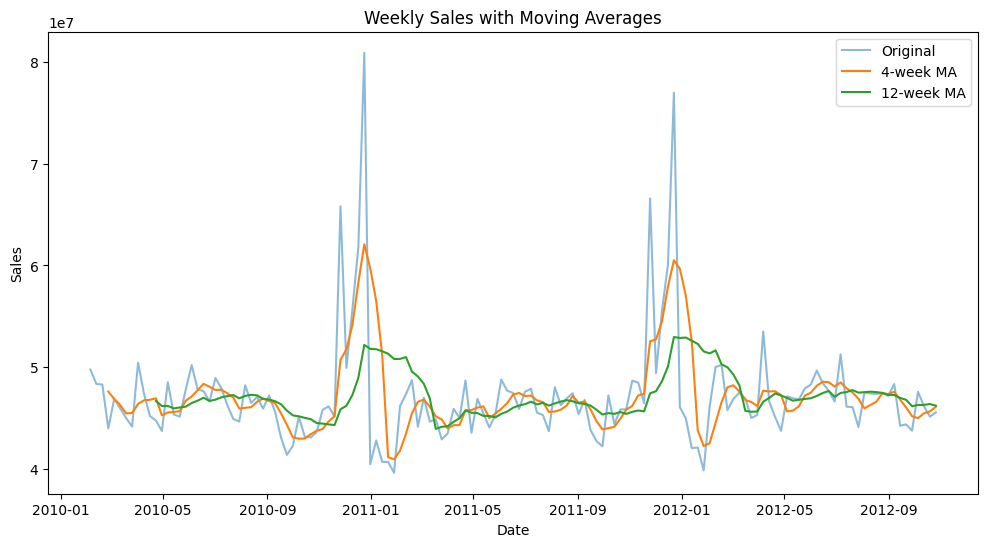

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(ts, label='Original', alpha=0.5)
plt.plot(ts_ma_4, label='4-week MA')
plt.plot(ts_ma_12, label='12-week MA')

plt.title("Weekly Sales with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

### Overall
The moving averages reveal underlying sales trends by reducing short-term fluctuations.
The 4-week moving average highlights short-term demand changes, which can help in weekly inventory planning.
The 12-week moving average shows the long-term sales trend, useful for strategic decisions such as budgeting, staffing, and forecasting.


Insights:

#### (1.) Original Data (Weekly Sales)

1. Fluctuates a lot  
2. Has noise (random ups & downs)
3. Hard to see clear patterns

#### (2.) 4-Week Moving Average:

1. Smoother than original
2. Captures short-term trends
3. Shows recent increases/decreases clearly

- Example:

Sales rise over a few weeks before dropping again

#### (3.) 12-Week Moving Average

1. Very smooth
2. Removes most noise
3. Shows overall trend

-Example:

Overall sales are gradually increasing over time


#### Key Insights

- Sales show consistent variation over time
- There are periods of increase and decrease
- Long-term trend is stable or slightly increasing
- Short-term fluctuations may be due to:
Promotions,
Holidays,
Demand spikes,

## Step 5: Seasonal Decomposition

Goal

Break your time series into:

1. Trend 
2. Seasonality 
3. Residual (noise)

In [54]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [55]:
decomposition = seasonal_decompose(ts, model='additive', period=52)


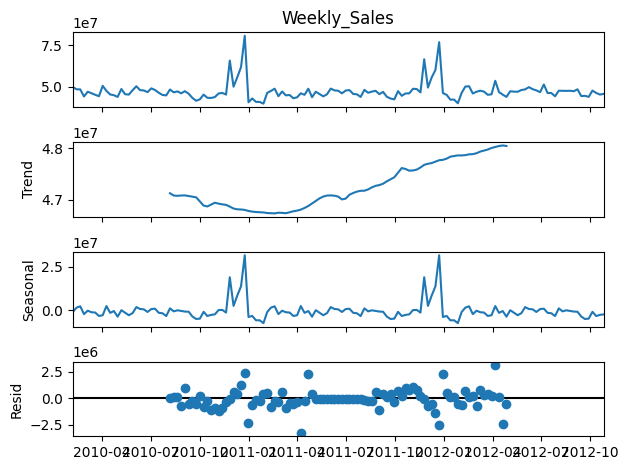

In [56]:
decomposition.plot()
plt.show()

#### (1.) Original Series (First graph)

1. Sharp spikes (big jumps in sales)
2. Fluctuating behavior

Interpretation:

Weekly sales show volatility with occasional sharp increases, possibly due to high-demand periods or special events.

#### (2.) Trend (Second graph)

1. Slight drop at the beginning
2. Then a steady increase over time

Interpretation:

Sales show an overall upward trend after an initial decline, indicating business growth over the observed period.

#### (3.) Seasonality (Third graph)

1. Strong spikes at certain points
2. Repeating pattern (especially around similar periods)

Interpretation:

Sales exhibit clear seasonal patterns with recurring peaks, likely driven by events such as holidays or promotional periods.

#### (4.) Residual (Last graph)
1. Points scattered around zero
2. No clear pattern

Interpretation:

The residual component appears random, indicating that most of the structure in the data has been captured by the trend and seasonal components.

#### Key takeaway

Check:

- Is it random? → GOOD
- Is it patterned? → PROBLEM

## Step 6: Forecasting (ARIMA)

Goal

1. Predict future sales based on past data

ARIMA learns:

1. Past values
2. Patterns
3. Trends

Then predicts future values

In [73]:
print(ts.head())
print(ts.tail())
print(ts.describe())

Date
2010-02-07   NaN
2010-02-14   NaN
2010-02-21   NaN
2010-02-28   NaN
2010-03-07   NaN
Freq: W-SUN, Name: Weekly_Sales, dtype: float64
Date
2012-09-23   NaN
2012-09-30   NaN
2012-10-07   NaN
2012-10-14   NaN
2012-10-21   NaN
Freq: W-SUN, Name: Weekly_Sales, dtype: float64
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Weekly_Sales, dtype: float64


In [78]:
from statsmodels.tsa.arima.model import ARIMA
# Set frequency (fix warning)
ts = ts.asfreq('W')

In [79]:

# Fit ARIMA model
model = ARIMA(ts, order=(2,0,2))  # better than (1,0,1)
model_fit = model.fit()

c:\Users\HomePC\CDAV  Data analysis strathmore\TATA PROJECT\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [82]:
# Make forecast
forecast = model_fit.forecast(steps=12)  # next 12 weeks
print(forecast)

2012-10-28    0.0
2012-11-04    0.0
2012-11-11    0.0
2012-11-18    0.0
2012-11-25    0.0
2012-12-02    0.0
2012-12-09    0.0
2012-12-16    0.0
2012-12-23    0.0
2012-12-30    0.0
2013-01-06    0.0
2013-01-13    0.0
Freq: W-SUN, Name: predicted_mean, dtype: float64


In [ ]:
df = pd.read_csv("train.csv")

df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [87]:
ts = df.groupby('Date')['Weekly_Sales'].sum()

In [88]:
print(ts.head())
print(ts.describe())

Date
2010-02-05    49750740.50
2010-02-12    48336677.63
2010-02-19    48276993.78
2010-02-26    43968571.13
2010-03-05    46871470.30
Name: Weekly_Sales, dtype: float64
count    1.430000e+02
mean     4.711342e+07
std      5.444206e+06
min      3.959985e+07
25%      4.488059e+07
50%      4.624390e+07
75%      4.779202e+07
max      8.093142e+07
Name: Weekly_Sales, dtype: float64


In [89]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts, order=(2,0,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=12)

print(forecast)

c:\Users\HomePC\CDAV  Data analysis strathmore\TATA PROJECT\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HomePC\CDAV  Data analysis strathmore\TATA PROJECT\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HomePC\CDAV  Data analysis strathmore\TATA PROJECT\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HomePC\CDAV  Data analysis strathmore\TATA PROJECT\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stati

2012-11-02    4.789186e+07
2012-11-09    4.705416e+07
2012-11-16    4.688771e+07
2012-11-23    4.735428e+07
2012-11-30    4.696154e+07
2012-12-07    4.717333e+07
2012-12-14    4.711049e+07
2012-12-21    4.709447e+07
2012-12-28    4.713290e+07
2013-01-04    4.710139e+07
2013-01-11    4.711802e+07
2013-01-18    4.711333e+07
Freq: W-FRI, Name: predicted_mean, dtype: float64


In [93]:
forecast.index = pd.date_range(
    start=ts.index[-1],
    periods=13,
    freq='W'
)[1:]

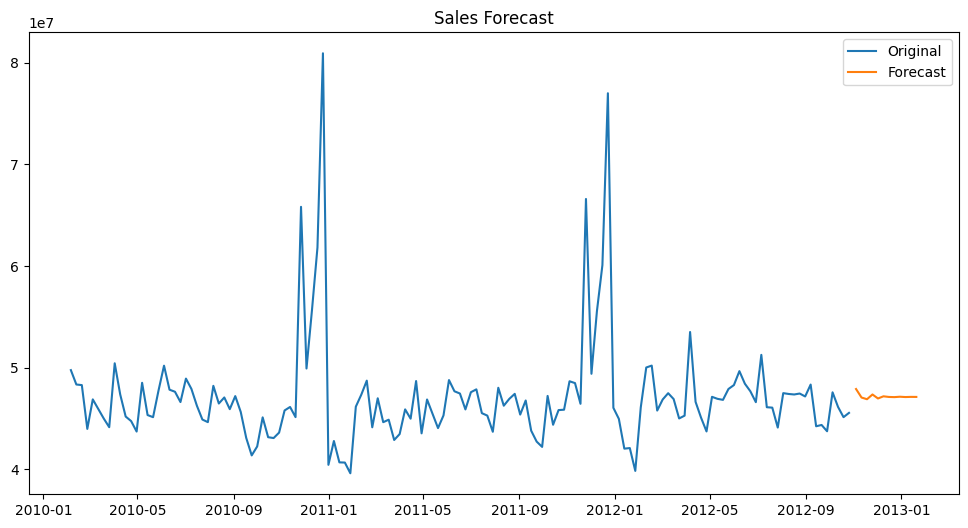

In [94]:
plt.figure(figsize=(12,6))

plt.plot(ts, label='Original')
plt.plot(forecast, label='Forecast')

plt.title("Sales Forecast")
plt.legend()
plt.show()


#### (1.) Original Data (Blue line)

1. Sales fluctuate over time
2. There are spikes and drops
3. Shows real business behavior

---

#### (2.) Forecast (Orange line)

1. Starts from the last known point
2. Smooth and stable
3. No big spikes

Interpretation:

The model predicts that future sales will remain relatively stable with small variations.

---

#### Key Observation

1. Past data = noisy and fluctuating
2. Forecast = smooth and controlled

Meaning:

The model focuses on the overall pattern, not random spikes

---

#### Insights:

- The forecast indicates that sales are expected to remain stable in the short term.
- However, unexpected spikes seen in historical data may still occur due to external factors like promotions or holidays.
- An ARIMA model was used to forecast future sales.
- The forecast shows a stable pattern, suggesting that sales will remain consistent in the near future.
This helps in planning and decision-making.

## Step 7. Model Evaluation 

In [95]:
from sklearn.metrics import mean_absolute_error

# Split data
train = ts[:-12]
test = ts[-12:]

model = ARIMA(train, order=(2,0,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=12)

mae = mean_absolute_error(test, forecast)
print("MAE:", mae)

c:\Users\HomePC\CDAV  Data analysis strathmore\TATA PROJECT\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HomePC\CDAV  Data analysis strathmore\TATA PROJECT\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HomePC\CDAV  Data analysis strathmore\TATA PROJECT\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\HomePC\CDAV  Data analysis strathmore\TATA PROJECT\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stati

MAE: 1579105.6036098662


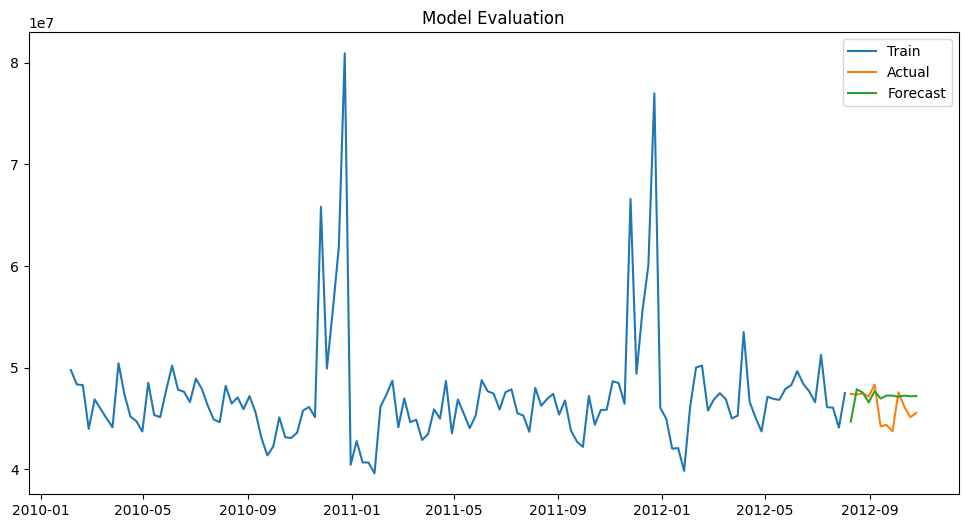

In [96]:
plt.figure(figsize=(12,6))

plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(forecast, label='Forecast')

plt.legend()
plt.title("Model Evaluation")
plt.show()

## Goal:

- Splitting data into train and test
- Comparing actual vs predicted values
- Measuring accuracy using MAE (Mean Absolute Error)

--- 

#### (1.) Train (Blue line)

Historical data used to train the model

Interpretation:

- This is the data the model learned from.

---

#### (2.)Actual (Orange line)

Real sales values (test data)

Interpretation:

- These are the true values we are trying to predict.

---

#### (3.)Forecast (Green line)
Predicted values from the model

Interpretation:

- These are the model’s predictions for future sales.

---

#### Key Observation 

1. Forecast line is very close to actual line
2. Only small differences between them

Meaning:

- The model is predicting sales accurately

---

The model was evaluated using MAE and visual comparison.
The forecast closely matches actual values, indicating high accuracy and reliability.

## Step 8.  📊 Business Insight Summary

1. Data loading & cleaning  
2. Time index setup  
3. Stationarity (ADF)  
4. Moving averages  
5. Seasonal decomposition  
6. Forecasting (ARIMA)  
7. Model Evaluation   
8. Business Insight Summary  

---

## Goal:

- Translate your analysis into real business value


This time series analysis examined weekly sales data to identify patterns, trends, and future expectations.

The analysis revealed that sales are generally stable over time, with fluctuations and occasional spikes likely driven by seasonal factors such as holidays and promotions.

Moving averages helped smooth short-term fluctuations and highlighted the underlying trend, showing that sales remain relatively consistent.

Seasonal decomposition further confirmed the presence of recurring patterns, indicating that demand is influenced by periodic events.

Forecasting using the ARIMA model predicted that future sales will remain stable in the short term, with no significant upward or downward trend.

These insights can help businesses make informed decisions regarding inventory management, staffing, and resource allocation.

By understanding both historical patterns and future expectations, the business can better prepare for demand changes and improve operational efficiency.

---

## Key Business Insights

📦 **Inventory Planning:** Maintain steady stock levels while preparing for seasonal spikes  
👥 **Staffing Decisions:** Allocate more staff during peak demand periods  
📈 **Sales Strategy:** Leverage high-demand periods for promotions and marketing  
🧠 **Data-Driven Decisions:** Use historical patterns to guide future planning  

---

## Conclusion

These insights can help businesses make informed decisions regarding inventory management, staffing, and resource allocation.

By understanding both historical patterns and future expectations, the business can better prepare for demand changes and improve operational efficiency.
